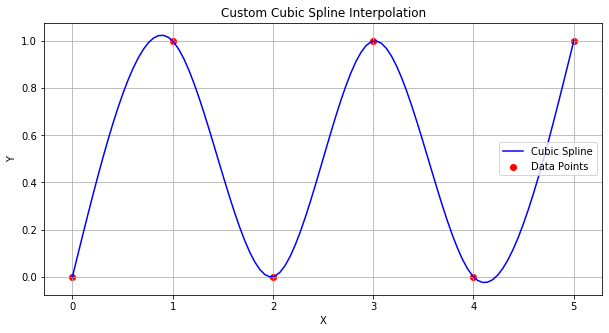

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def thomas_algorithm(a, b, c, d):
    n = len(b)
    be = np.array(b, dtype=float)
    de = np.array(d, dtype=float)
    
    for i in range(1, n):
        w = a[i-1] / be[i-1]
        be[i] = be[i] - w * c[i-1]
        de[i] = de[i] - w * de[i-1]
    
    x = np.zeros(n)
    x[-1] = de[-1] / be[-1]
    for i in range(n-2, -1, -1):
        x[i] = (de[i] - c[i] * x[i+1]) / be[i]
    return x

def cubic_spline(x, y):
    n = len(x)
    h = np.diff(x) 
    
    diagonal_b = 2 * (h[:-1] + h[1:])
    sub_a = h[1:-1]
    super_c = h[1:-1]
    
    rhs_d = 6 * ((y[2:] - y[1:-1]) / h[1:] - (y[1:-1] - y[:-2]) / h[:-1])

    m_interior = thomas_algorithm(sub_a, diagonal_b, super_c, rhs_d)
    
    M = np.zeros(n)
    M[1:-1] = m_interior
    
    def evaluate_spline(x_evaluated):
        if x_evaluated < x[0] or x_evaluated > x[-1]:
            return None 
            
        i = np.searchsorted(x, x_evaluated) - 1
        i = max(0, min(i, n - 2)) 
        
        dx = x_evaluated - x[i]
        h_i = h[i]
        
        t1 = M[i] * (x[i+1] - x_evaluated)**3 / (6 * h_i)
        t2 = M[i+1] * (x_evaluated - x[i])**3 / (6 * h_i)
        t3 = (y[i] - (M[i] * h_i**2)/6) * (x[i+1] - x_evaluated) / h_i
        t4 = (y[i+1] - (M[i+1] * h_i**2)/6) * (x_evaluated - x[i]) / h_i
        
        return t1 + t2 + t3 + t4

    return evaluate_spline

x_data = np.array([0, 1, 2, 3, 4, 5])
y_data = np.array([0, 1, 0, 1, 0, 1]) 

spline_function = cubic_spline(x_data, y_data)

x_vals = np.linspace(x_data[0], x_data[-1], 100)
y_vals = [spline_function(val) for val in x_vals]

plt.figure(figsize=(10, 5))
plt.plot(x_vals, y_vals, label='Cubic Spline', color='blue')
plt.scatter(x_data, y_data, color='red', label='Data Points')
plt.title('Custom Cubic Spline Interpolation')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()
